# Thick cylinders in axial compression and under combined loads: Kardomateas (1993b), Kardomateas and Philobos (1995)

G. A. Kardomateas, *Stability loss in thick transversely isotropic cylindrical shells under axial compression*, Journal of Applied Mechanics 60 (1993) 506-513.

G. A. Kardomateas and M. S. Philobos, *Buckling of thick orthotropic cylindrical shells under combined external pressure and axial compression*, AIAA Journal 33 (1995) 1946-1953, https://doi.org/10.2514/3.12750.

Thick single-layer cylinders with simply supported (shear-diaphragm) ends, with the 3D elasticity solutions of the bifurcation problem as reference:

- **(a) Axial compression**, Kardomateas (1993b): outer radius $R_2 = 1$ m, length $l = 5 R_2$, $R_2/R_1$ = 1.15 to 1.30, isotropic, $E = 14$ GPa, $\nu = 0.3$ (Tables 1 and 2, with the values of a Flügge-type shell theory), and $R_2/R_1$ = 1.10 to 1.30, transversely isotropic in the $r\theta$ plane with the fibres along the axis, $E_3 = 57$ (axial), $E_1 = E_2 = 14$, $G_{31} = G_{23} = 5.7$ GPa, $\nu_{12} = 0.400$, $\nu_{23} = \nu_{13} = 0.068$ (Table 3). Buckling stress $\bar\sigma = \sigma_0 R_2/(E_3 h)$, $h = R_2 - R_1$.
- **(b) External pressure and axial compression**, Kardomateas and Philobos (1995): outer radius $b = 1$ m, inner radius $a$, $l/b = 5$, $b/a$ = 1.03 to 1.25, orthotropic with the reinforcement along the hoop direction (1 = r, 2 = $\theta$, 3 = z): glass/epoxy, $E_1 = 14$, $E_2 = 57$, $E_3 = 14$, $G_{12} = 5.7$, $G_{23} = 5.7$, $G_{31} = 5.0$ GPa, $\nu_{12} = 0.068$, $\nu_{23} = 0.277$, $\nu_{31} = 0.400$ (Table 1), and graphite/epoxy, $E_1 = 9.9$, $E_2 = 140$, $E_3 = 9.1$, $G_{12} = 4.7$, $G_{23} = 4.3$, $G_{31} = 5.9$ GPa, $\nu_{12} = 0.020$, $\nu_{23} = 0.300$, $\nu_{31} = 0.490$ (Table 2); a hydrostatic external pressure $p$ on the outer surface combined with the axial load $P = 2\pi S p b^2$, Eq. (13), with the load interaction parameters $S = 5$ and 1; critical pressure $\bar{p} = p b^3/(E_2 h^3)$, Eq. (24). The tables also give the critical loads of the nonshallow Donnell and of the Timoshenko shell theories.

The 3D data are those of `REFERENCE_DATA.md` of the paper study, copied in `scf_validation_utils.py`. The Donnell and Timoshenko values of Kardomateas and Philobos, `su.KP1995_SHELLS`, were transcribed from their Tables 1 and 2 for this notebook; each value is consistent with the percentage over the elasticity value printed below it.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import scf_validation_utils as su
from scf_validation_utils import pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## panels model

The closed cylinder of mid-surface radius $R = (R_1 + R_2)/2$ and thickness $h = R_2 - R_1$ is represented by a shear-diaphragm panel of angle $\pi$, $0 \le y \le \pi R$, with the condition `'D'` on the four edges, `su.finite_cylinder`, which contains every mode with $n \ge 1$ circumferential waves (the cuts at $y = 0, \pi R$ are nodal lines of $\sin(n y/R)$), with 20 axial and 10 circumferential terms and the Sanders kinematics, `cylshell_clpt_sanders`, `cylshell_fsdt_sanders` (with $\kappa = 5/6$) and `cylshell_tsdt_sanders`. For a single homogeneous layer, `'rohwer'` and the other static corrections give $\kappa = 5/6$.

- **(a)** The membrane prestate $N_{xx} = -1$, `lb(kC, kG)`, $\sigma_0 = N_{xx, cr}/h$. Laminate axes $x$ = axial, $y$ = hoop: isotropic `(14., 0.3)`, transversely isotropic `(E11, E22, nu12, G12, G13, G23) = (57, 14, 0.068*57/14, 5.7, 5.7, 14/(2*1.4))`.
- **(b)** A follower pressure on the outer surface, `add_pressure_load(-1., cte=False, follower=True, zp=h/2)`, applied as $p(1 + h/(2R))$ per unit mid-surface area, with the hoop prestate $N_{yy} = -p(R + h/2)$ and the axial prestate of $P$ on the circumference $2\pi R$, $N_{xx} = -S p b^2/R$, and `lb(kC, kG + kCfollower)`, an unsymmetric problem, `su.cylinder_pressure`. The plies are at 90 deg (fibres along the hoop), with `(E11, E22, nu12, G12, G13, G23) = (E2, E3, nu23, G23, G12, G31)` in the notation of the reference: $G_{13}$ of the ply, the transverse shear stiffness `A44` of the hoop direction, is the $r\theta$ modulus $G_{12}$.

The numbers of half-waves of the critical mode of panels are counted with `su.halfwaves` and given as $(n, m)$, $n$ circumferential waves and $m$ axial half-waves, as in the papers.

In [2]:
GPa = 1e9
# (a) Kardomateas (1993b), laminate axes x = axial, y = hoop
ISOTROPIC = (14., 0.3)
TRANSV_ISO = (57., 14., 0.068*57/14, 5.7, 5.7, 14/(2*1.4))
E3 = {'isotropic': 14., 'transversely isotropic': 57.}
# (b) Kardomateas and Philobos (1995), plies at 90 deg
KARD_GLASS = (57.*GPa, 14.*GPa, 0.277, 5.7*GPa, 5.7*GPa, 5.0*GPa)
KARD_GRAPHITE = (140.*GPa, 9.1*GPa, 0.300, 4.3*GPa, 4.7*GPa, 5.9*GPa)
E2_1995 = {'glass': 57.*GPa, 'graphite': 140.*GPa}
L_B = 5.
MX, MY = 20, 10
MODELS = [('CLPT', 'clpt', 'K56'), ('FSDT-K56', 'fsdt', 'K56'), ('TSDT', 'tsdt', 'K56')]


def axial_sigma(theory, material, ratio):
    R2 = 1.
    R1 = R2/ratio
    R = (R1 + R2)/2
    h = R2 - R1
    lp = ISOTROPIC if material == 'isotropic' else TRANSV_ISO
    s = su.finite_cylinder(theory, 'K56', R, 5*R2, [0], [h], [lp], [1.], mx=MX, my=MY)
    s.Nxx = -1.
    lbd, mode = su.linear_buckling(s)
    m, n = su.halfwaves(s, mode)
    return dict(sigma=lbd/h*R2/(E3[material]*h), nm=(n, m))


def combined_pbar(theory, material, S, ratio):
    b = 1.
    a = b/ratio
    h = b - a
    R = (a + b)/2
    mat = KARD_GLASS if material == 'glass' else KARD_GRAPHITE
    s = su.finite_cylinder(theory, 'K56', R, L_B*b, [90.], [h], [mat], [1.], mx=MX, my=MY)
    # P = 2 pi S p b^2 acting on the circumference 2 pi R
    p, (m, n) = su.cylinder_pressure(s, zp=h/2, Nxx_per_p=-S*b**2/R, mode=True)
    return dict(p=p*b**3/(E2_1995[material]*h**3), nm=(n, m))


def compute():
    res = {}
    for material, refs in su.KARDOMATEAS_1993B.items():
        for ratio in refs:
            res['a %s %.2f' % (material, ratio)] = {label: axial_sigma(theory, material, ratio)
                                                    for label, theory, _ in MODELS}
    for (material, S), refs in su.KARDOMATEAS_1995.items():
        for ratio, *_ in refs:
            res['b %s S%d %.2f' % (material, S, ratio)] = {label: combined_pbar(theory, material, S, ratio)
                                                           for label, theory, _ in MODELS}
    return res


res = su.run_or_load(os.path.join(RESULTS, 'kardomateas1993b_1995_thick_cylinders.json'), compute, rerun=RERUN)
LABELS = [m[0] for m in MODELS]
nm = lambda v: '(%d,%d)' % tuple(v)

## (a) Axial compression, Kardomateas (1993b)

$\bar\sigma = \sigma_0 R_2/(E_3 h)$ and the mode $(n, m)$, with the difference to the elasticity solution in parentheses. The Flügge-type shell values are those of Table 2 of the paper (isotropic only).

In [3]:
for material, refs in su.KARDOMATEAS_1993B.items():
    rows = []
    for ratio, ref in refs.items():
        r = res['a %s %.2f' % (material, ratio)]
        fl = su.FLUGGE_1993B.get(ratio) if material == 'isotropic' else None
        rows.append(['%.2f' % ratio, '%.3f %s' % (ref, nm(su.KARDOMATEAS_1993B_MODES[material][ratio])),
                     '-' if fl is None else '%.3f (%+.1f%%)' % (fl, pct(fl, ref))]
                    + ['%.4f %s (%+.1f%%)' % (r[m]['sigma'], nm(r[m]['nm']), pct(r[m]['sigma'], ref)) for m in LABELS])
    display(Markdown('**%s**' % material))
    display(Markdown(markdown_table(['$R_2/R_1$', 'elasticity', 'Flügge'] + ['panels ' + m for m in LABELS], rows)))
cols = {m: [pct(res['a %s %.2f' % (mat, ratio)][m]['sigma'], ref) for mat, refs in su.KARDOMATEAS_1993B.items()
            for ratio, ref in refs.items()] for m in LABELS}
cols['Flügge (isotropic)'] = [pct(su.FLUGGE_1993B[ratio], ref) for ratio, ref in su.KARDOMATEAS_1993B['isotropic'].items()]
display(Markdown('**All cylinders of part (a)**'))
display(Markdown(su.stats_table(cols)))
spread = [100*(max(r[m]['sigma'] for m in ('FSDT-K56', 'TSDT')) - min(r[m]['sigma'] for m in ('FSDT-K56', 'TSDT')))
          / min(r[m]['sigma'] for m in ('FSDT-K56', 'TSDT')) for k, r in res.items() if k.startswith('a ')]
print('largest difference FSDT-K56 / TSDT: %.3f%%' % max(spread))

**isotropic**

| $R_2/R_1$ | elasticity | Flügge | panels CLPT | panels FSDT-K56 | panels TSDT |
|---|---|---|---|---|---|
| 1.15 | 0.454 (2,1) | 0.471 (+3.7%) | 0.5452 (2,2) (+20.1%) | 0.5400 (2,2) (+19.0%) | 0.5400 (2,2) (+19.0%) |
| 1.20 | 0.437 (2,2) | 0.462 (+5.7%) | 0.5223 (2,2) (+19.5%) | 0.5108 (2,2) (+16.9%) | 0.5108 (2,2) (+16.9%) |
| 1.25 | 0.443 (2,2) | 0.473 (+6.8%) | 0.5340 (2,2) (+20.5%) | 0.5131 (2,2) (+15.8%) | 0.5131 (2,2) (+15.8%) |
| 1.30 | 0.449 (1,1) | 0.492 (+9.6%) | 0.5631 (2,2) (+25.4%) | 0.5295 (2,2) (+17.9%) | 0.5295 (2,2) (+17.9%) |

**transversely isotropic**

| $R_2/R_1$ | elasticity | Flügge | panels CLPT | panels FSDT-K56 | panels TSDT |
|---|---|---|---|---|---|
| 1.10 | 0.167 (2,1) | - | 0.1933 (3,3) (+15.7%) | 0.1892 (3,3) (+13.3%) | 0.1892 (3,3) (+13.3%) |
| 1.15 | 0.162 (2,1) | - | 0.1925 (2,1) (+18.8%) | 0.1900 (2,1) (+17.3%) | 0.1900 (2,1) (+17.3%) |
| 1.20 | 0.164 (2,2) | - | 0.1849 (2,2) (+12.7%) | 0.1803 (2,2) (+10.0%) | 0.1804 (2,2) (+10.0%) |
| 1.25 | 0.163 (2,2) | - | 0.1851 (2,2) (+13.6%) | 0.1771 (2,2) (+8.6%) | 0.1771 (2,2) (+8.6%) |
| 1.30 | 0.167 (2,2) | - | 0.1914 (2,2) (+14.6%) | 0.1787 (2,2) (+7.0%) | 0.1787 (2,2) (+7.0%) |

**All cylinders of part (a)**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 25.4 | 17.9 | +12.7 to +25.4 |
| FSDT-K56 | 19.0 | 14.0 | +7.0 to +19.0 |
| TSDT | 19.0 | 14.0 | +7.0 to +19.0 |
| Flügge (isotropic) | 9.6 | 6.5 | +3.7 to +9.6 |

largest difference FSDT-K56 / TSDT: 0.010%


## (b) External pressure and axial compression, Kardomateas and Philobos (1995)

$\bar{p} = p b^3/(E_2 h^3)$ and the mode $(n, m)$, with the difference to the elasticity solution in parentheses, for the elasticity solution, the nonshallow Donnell and the Timoshenko shell theories of the paper, and panels.

In [4]:
for (material, S), refs in su.KARDOMATEAS_1995.items():
    rows = []
    for ratio, ref, Pref, nm3d in refs:
        r = res['b %s S%d %.2f' % (material, S, ratio)]
        (d, dnm), (t, tnm) = su.KP1995_SHELLS[(material, S)][ratio]
        rows.append(['%.2f' % ratio, '%.4f %s' % (ref, nm(nm3d)), '%.4f %s (%+.1f%%)' % (d, nm(dnm), pct(d, ref)),
                     '%.4f %s (%+.1f%%)' % (t, nm(tnm), pct(t, ref))]
                    + ['%.4f %s (%+.1f%%)' % (r[m]['p'], nm(r[m]['nm']), pct(r[m]['p'], ref)) for m in LABELS])
    display(Markdown('**%s/epoxy, S = %d**' % (material, S)))
    display(Markdown(markdown_table(['$b/a$', 'elasticity', 'Donnell', 'Timoshenko'] + ['panels ' + m for m in LABELS], rows)))

**glass/epoxy, S = 5**

| $b/a$ | elasticity | Donnell | Timoshenko | panels CLPT | panels FSDT-K56 | panels TSDT |
|---|---|---|---|---|---|---|
| 1.03 | 0.5561 (2,1) | 0.6209 (2,1) (+11.7%) | 0.5653 (2,1) (+1.7%) | 0.6272 (2,1) (+12.8%) | 0.6245 (3,1) (+12.3%) | 0.6245 (3,1) (+12.3%) |
| 1.05 | 0.3014 (2,1) | 0.3435 (2,1) (+14.0%) | 0.3130 (2,1) (+3.8%) | 0.3419 (2,1) (+13.5%) | 0.3402 (2,1) (+12.9%) | 0.3402 (2,1) (+12.9%) |
| 1.10 | 0.1971 (2,1) | 0.2371 (2,1) (+20.3%) | 0.2165 (2,1) (+9.8%) | 0.2284 (2,1) (+15.9%) | 0.2217 (2,1) (+12.5%) | 0.2217 (2,1) (+12.5%) |
| 1.15 | 0.1665 (2,2) | 0.2218 (2,2) (+33.2%) | 0.1886 (2,2) (+13.3%) | 0.2039 (2,2) (+22.5%) | 0.1958 (2,2) (+17.6%) | 0.1958 (2,2) (+17.6%) |
| 1.20 | 0.1335 (2,2) | 0.1909 (2,2) (+43.0%) | 0.1624 (2,2) (+21.6%) | 0.1696 (2,2) (+27.1%) | 0.1560 (2,2) (+16.8%) | 0.1560 (2,2) (+16.9%) |
| 1.25 | 0.1167 (1,1) | 0.1753 (2,3) (+50.2%) | 0.1241 (1,1) (+6.3%) | 0.1476 (2,3) (+26.4%) | 0.1332 (2,3) (+14.1%) | 0.1332 (2,3) (+14.2%) |

**glass/epoxy, S = 1**

| $b/a$ | elasticity | Donnell | Timoshenko | panels CLPT | panels FSDT-K56 | panels TSDT |
|---|---|---|---|---|---|---|
| 1.03 | 0.7311 (3,1) | 0.7518 (3,1) (+2.8%) | 0.7480 (3,1) (+2.3%) | 0.7470 (3,1) (+2.2%) | 0.7414 (3,1) (+1.4%) | 0.7414 (3,1) (+1.4%) |
| 1.05 | 0.4666 (2,1) | 0.4965 (2,1) (+6.4%) | 0.4829 (2,1) (+3.5%) | 0.5050 (2,1) (+8.2%) | 0.5024 (2,1) (+7.7%) | 0.5024 (2,1) (+7.7%) |
| 1.10 | 0.3038 (2,1) | 0.3386 (2,1) (+11.5%) | 0.3297 (2,1) (+8.5%) | 0.3349 (2,1) (+10.2%) | 0.3251 (2,1) (+7.0%) | 0.3251 (2,1) (+7.0%) |
| 1.15 | 0.2758 (2,1) | 0.3235 (2,1) (+17.3%) | 0.3152 (2,1) (+14.3%) | 0.3121 (2,1) (+13.2%) | 0.2911 (2,1) (+5.6%) | 0.2911 (2,1) (+5.6%) |
| 1.20 | 0.2659 (2,1) | 0.3297 (2,1) (+24.0%) | 0.3214 (2,1) (+20.9%) | 0.3107 (2,1) (+16.9%) | 0.2757 (2,1) (+3.7%) | 0.2757 (2,1) (+3.7%) |
| 1.25 | 0.2600 (2,1) | 0.3418 (2,1) (+31.5%) | 0.3334 (2,1) (+28.2%) | 0.3154 (2,1) (+21.3%) | 0.2643 (2,1) (+1.7%) | 0.2644 (2,1) (+1.7%) |

**graphite/epoxy, S = 5**

| $b/a$ | elasticity | Donnell | Timoshenko | panels CLPT | panels FSDT-K56 | panels TSDT |
|---|---|---|---|---|---|---|
| 1.03 | 0.2511 (2,1) | 0.2845 (2,1) (+13.3%) | 0.2591 (2,1) (+3.2%) | 0.2877 (2,1) (+14.6%) | 0.2860 (2,1) (+13.9%) | 0.2860 (2,1) (+13.9%) |
| 1.05 | 0.1826 (2,1) | 0.2137 (2,1) (+17.0%) | 0.1949 (2,1) (+6.7%) | 0.2132 (2,1) (+16.7%) | 0.2085 (2,1) (+14.2%) | 0.2085 (2,1) (+14.2%) |
| 1.10 | 0.1125 (2,2) | 0.1519 (2,2) (+35.0%) | 0.1290 (2,2) (+14.7%) | 0.1455 (2,2) (+29.3%) | 0.1369 (3,8) (+21.7%) | 0.1369 (3,8) (+21.7%) |
| 1.15 | 0.0754 (2,3) | 0.1092 (2,4) (+44.8%) | 0.0819 (1,1) (+8.6%) | 0.0978 (2,4) (+29.8%) | 0.0910 (2,3) (+20.6%) | 0.0910 (2,3) (+20.7%) |
| 1.20 | 0.0483 (1,1) | 0.0867 (2,5) (+79.5%) | 0.0501 (1,1) (+3.7%) | 0.0743 (2,5) (+53.7%) | 0.0656 (2,4) (+35.8%) | 0.0656 (2,4) (+35.9%) |
| 1.25 | 0.0324 (1,1) | 0.0696 (1,1) (+114.8%) | 0.0348 (1,1) (+7.4%) | 0.0630 (2,5) (+94.5%) | 0.0517 (2,5) (+59.6%) | 0.0518 (2,5) (+59.7%) |

**graphite/epoxy, S = 1**

| $b/a$ | elasticity | Donnell | Timoshenko | panels CLPT | panels FSDT-K56 | panels TSDT |
|---|---|---|---|---|---|---|
| 1.03 | 0.3899 (2,1) | 0.4134 (2,1) (+6.0%) | 0.4019 (2,1) (+3.1%) | 0.4263 (2,1) (+9.3%) | 0.4237 (2,1) (+8.7%) | 0.4237 (2,1) (+8.7%) |
| 1.05 | 0.2834 (2,1) | 0.3090 (2,1) (+9.0%) | 0.3005 (2,1) (+6.0%) | 0.3149 (2,1) (+11.1%) | 0.3080 (2,1) (+8.7%) | 0.3080 (2,1) (+8.7%) |
| 1.10 | 0.2352 (2,1) | 0.2793 (2,1) (+18.8%) | 0.2719 (2,1) (+15.6%) | 0.2768 (2,1) (+17.7%) | 0.2514 (2,1) (+6.9%) | 0.2514 (2,1) (+6.9%) |
| 1.15 | 0.2140 (2,2) | 0.2880 (2,1) (+34.6%) | 0.2704 (2,2) (+26.4%) | 0.2782 (2,1) (+30.0%) | 0.2272 (2,1) (+6.2%) | 0.2273 (2,1) (+6.2%) |
| 1.20 | 0.1810 (2,2) | 0.2815 (2,2) (+55.5%) | 0.2505 (1,1) (+38.4%) | 0.2715 (2,2) (+50.0%) | 0.2059 (2,1) (+13.7%) | 0.2061 (2,1) (+13.9%) |
| 1.25 | 0.1597 (2,2) | 0.2743 (2,3) (+71.8%) | 0.1737 (1,1) (+8.8%) | 0.2527 (2,4) (+58.2%) | 0.1787 (2,2) (+11.9%) | 0.1791 (2,2) (+12.1%) |

In [5]:
def errors(key, material, S):
    out = []
    for ratio, ref, *_ in su.KARDOMATEAS_1995[(material, S)]:
        if key in ('Donnell', 'Timoshenko'):
            v = su.KP1995_SHELLS[(material, S)][ratio][0 if key == 'Donnell' else 1][0]
        else:
            v = res['b %s S%d %.2f' % (material, S, ratio)][key]['p']
        out.append(pct(v, ref))
    return out


for case in su.KARDOMATEAS_1995:
    display(Markdown('**%s/epoxy, S = %d**' % case))
    display(Markdown(su.stats_table({k: errors(k, *case) for k in ['Donnell', 'Timoshenko'] + LABELS})))
rows = []
for case in su.KARDOMATEAS_1995:
    for i, (ratio, *_) in enumerate(su.KARDOMATEAS_1995[case]):
        e = {k: errors(k, *case)[i] for k in ('Donnell', 'Timoshenko', 'FSDT-K56')}
        rows.append(e['FSDT-K56'] - e['Donnell'])
print('FSDT-K56 minus Donnell: %+.1f to %+.1f percentage points, mean %+.1f' % (min(rows), max(rows), np.mean(rows)))
spread = [100*(max(r[m]['p'] for m in LABELS) - min(r[m]['p'] for m in LABELS))/min(r[m]['p'] for m in LABELS)
          for k, r in res.items() if k.startswith('b ')]
print('largest difference among CLPT, FSDT-K56 and TSDT: %.2f%%' % max(spread))

**glass/epoxy, S = 5**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| Donnell | 50.2 | 28.7 | +11.7 to +50.2 |
| Timoshenko | 21.6 | 9.4 | +1.7 to +21.6 |
| CLPT | 27.1 | 19.7 | +12.8 to +27.1 |
| FSDT-K56 | 17.6 | 14.4 | +12.3 to +17.6 |
| TSDT | 17.6 | 14.4 | +12.3 to +17.6 |

**glass/epoxy, S = 1**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| Donnell | 31.5 | 15.6 | +2.8 to +31.5 |
| Timoshenko | 28.2 | 13.0 | +2.3 to +28.2 |
| CLPT | 21.3 | 12.0 | +2.2 to +21.3 |
| FSDT-K56 | 7.7 | 4.5 | +1.4 to +7.7 |
| TSDT | 7.7 | 4.5 | +1.4 to +7.7 |

**graphite/epoxy, S = 5**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| Donnell | 114.8 | 50.8 | +13.3 to +114.8 |
| Timoshenko | 14.7 | 7.4 | +3.2 to +14.7 |
| CLPT | 94.5 | 39.8 | +14.6 to +94.5 |
| FSDT-K56 | 59.6 | 27.6 | +13.9 to +59.6 |
| TSDT | 59.7 | 27.7 | +13.9 to +59.7 |

**graphite/epoxy, S = 1**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| Donnell | 71.8 | 32.6 | +6.0 to +71.8 |
| Timoshenko | 38.4 | 16.4 | +3.1 to +38.4 |
| CLPT | 58.2 | 29.4 | +9.3 to +58.2 |
| FSDT-K56 | 13.7 | 9.3 | +6.2 to +13.7 |
| TSDT | 13.9 | 9.4 | +6.2 to +13.9 |

FSDT-K56 minus Donnell: -59.9 to +2.6 percentage points, mean -18.0
largest difference among CLPT, FSDT-K56 and TSDT: 41.42%


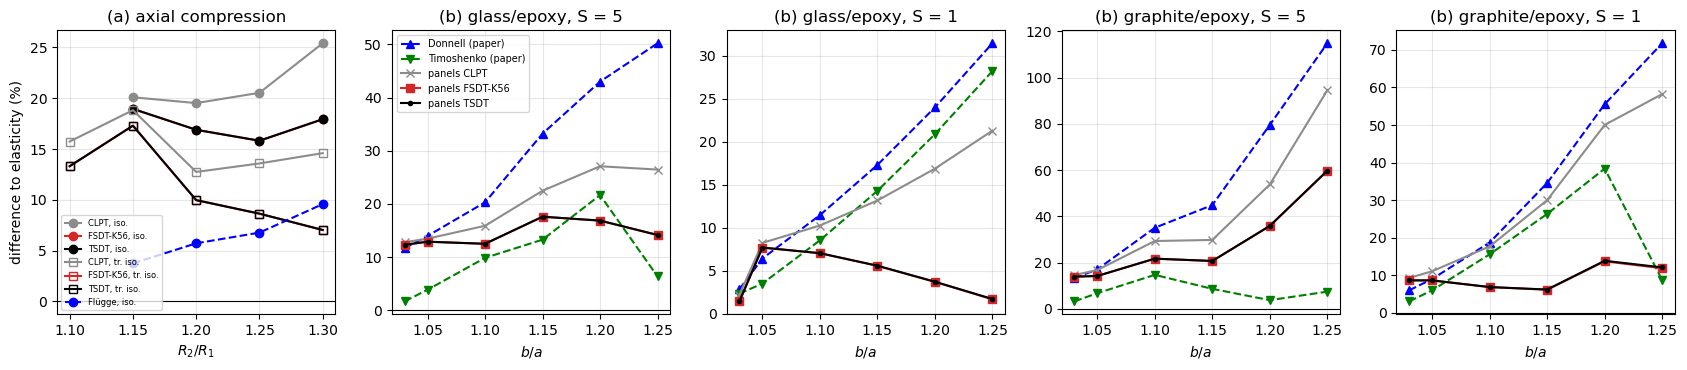

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
ax = axes[0]
for material, mk in (('isotropic', 'o'), ('transversely isotropic', 's')):
    ratios = list(su.KARDOMATEAS_1993B[material])
    for m, c in zip(LABELS, ('0.55', 'tab:red', 'k')):
        ax.plot(ratios, [pct(res['a %s %.2f' % (material, r)][m]['sigma'], su.KARDOMATEAS_1993B[material][r])
                         for r in ratios], color=c, marker=mk, mfc='none' if material != 'isotropic' else c,
                label='%s, %s' % (m, 'iso.' if material == 'isotropic' else 'tr. iso.'))
ratios = list(su.FLUGGE_1993B)
ax.plot(ratios, [pct(su.FLUGGE_1993B[r], su.KARDOMATEAS_1993B['isotropic'][r]) for r in ratios], 'b--o',
        label='Flügge, iso.')
ax.set_title('(a) axial compression')
ax.set_xlabel('$R_2/R_1$')
ax.set_ylabel('difference to elasticity (%)')
ax.legend(fontsize=6)
for ax, case in zip(axes[1:], su.KARDOMATEAS_1995):
    ratios = [r[0] for r in su.KARDOMATEAS_1995[case]]
    ax.plot(ratios, errors('Donnell', *case), 'b--^', label='Donnell (paper)')
    ax.plot(ratios, errors('Timoshenko', *case), 'g--v', label='Timoshenko (paper)')
    for m, c, mk in zip(LABELS, ('0.55', 'tab:red', 'k'), ('x', 's', '.')):
        ax.plot(ratios, errors(m, *case), color=c, marker=mk, label='panels ' + m)
    ax.set_title('(b) %s/epoxy, S = %d' % case)
    ax.set_xlabel('$b/a$')
axes[1].legend(fontsize=7)
for ax in axes:
    ax.axhline(0, color='k', lw=0.8)
    ax.grid(alpha=0.3)
plt.tight_layout()

## Discussion

- **Reproduction of the paper study.** The 9 buckling stresses of part (a) and the 72 critical pressures of part (b) are identical to those of the paper study (`C2A_kardomateas_axial.json` and `C2C_kardomateas_combined_parts`), computed with the same models and settings.
- **(a) Axial compression.** All models overestimate the 3D buckling stress: the FSDT and the TSDT by $+15.8\%$ to $+19.0\%$ for the isotropic cylinders and $+7.0\%$ to $+17.3\%$ for the transversely isotropic ones, the CLPT by $+12.7\%$ to $+25.4\%$. The FSDT with $\kappa = 5/6$ and the TSDT agree within 0.01%, and the transverse shear lowers the CLPT by at most 7.6 percentage points; no shear correction can remove the remaining error. The Flügge-type shell theory of the paper, which keeps the thickness-curvature terms, is only $+3.7\%$ to $+9.6\%$ above 3D. The error is a limitation of the kinematics and of the geometric stiffness of the shallow (Sanders) shell of panels, not of the transverse shear model.
- **(b) Combined loads, axial load dominant ($S = 5$).** For the thinnest cylinders, $b/a$ = 1.03 and 1.05 ($R/h$ = 34 and 21), the three models of panels are $+12.3\%$ to $+16.7\%$ above 3D, close to the nonshallow Donnell theory of the paper ($+11.7\%$ to $+17.0\%$) and far from its Timoshenko theory ($+1.7\%$ to $+6.7\%$), while the FSDT and the TSDT are within 2.5 percentage points of the CLPT. The Timoshenko theory differs from the Donnell theory by the prestress terms $-N_\theta^0(v_{,\theta z} + u_{,z})$ and $R N_z^0 v_{,zz}$, and Kardomateas and Philobos attribute the difference between the two under a large axial load to the latter; the geometric stiffness of panels, like the Donnell theory, lacks these terms, and for these cylinders the error of panels is kinematic. For the thicker cylinders the transverse shear becomes important, the FSDT being up to 35 percentage points below the CLPT (graphite/epoxy, $b/a = 1.25$), but the FSDT and the TSDT stay $+12.5\%$ to $+17.6\%$ (glass/epoxy) and $+20.6\%$ to $+59.6\%$ (graphite/epoxy) above 3D, well above the Timoshenko theory ($+3.7\%$ to $+14.7\%$ for graphite/epoxy), which has no transverse shear.
- **(b) Pressure dominant ($S = 1$).** Here the transverse shear governs the thick cylinders: the CLPT is up to $+21\%$ (glass/epoxy) and $+58\%$ (graphite/epoxy) above 3D, like the two classical theories of the paper (Donnell up to $+31.5\%$ and $+71.8\%$, Timoshenko up to $+28.2\%$ and $+38.4\%$), while the FSDT and the TSDT are $+1.4\%$ to $+7.7\%$ and $+6.2\%$ to $+13.9\%$ above 3D, closer than both shell theories of the paper for $b/a \ge 1.10$ (with the exception of the Timoshenko $(1, 1)$ value of graphite/epoxy at $b/a = 1.25$).
- **Shear correction.** In all 33 cylinders the FSDT with $\kappa = 5/6$ and the TSDT agree within 0.3 percentage points, so the choice of the shear correction (all static corrections give $5/6$ for one homogeneous layer) is irrelevant here. The remaining overestimation, 1.4% to 60%, is the kinematic limitation of the shell model (the shallow-shell metric and the geometric stiffness of the axial prestress), which is largest when the axial load dominates.
- **Modes.** panels finds the modes of the elasticity solution in most cases. The exceptions are $(3, 1)$ against $(2, 1)$ for glass/epoxy, $S = 5$, $b/a = 1.03$, probably two nearly coincident eigenvalues, and the modes with $m = 4, 5$ axial half-waves instead of $(1, 1)$ of the thickest graphite/epoxy cylinders with $S = 5$, $b/a$ = 1.20-1.25, as the $(2, 5)$ mode of the Donnell theory of the paper at $b/a = 1.20$, where the overestimation is the largest.